# Imports

In [14]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import cv2 as cv
import PIL
from PIL import Image

import sklearn
from sklearn.model_selection import train_test_split

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
from torch import optim
from torch.nn import functional as F

import torchvision
import torchvision.transforms as transforms
import torchvision.models as models

import tqdm
import torchmetrics as tm

# Load Data

In [15]:
data_path = './data/UTKFace/'
images_file = os.listdir(data_path)
len(images_file)

23708

## remove some invalid formated files name

In [16]:
# each file must be in format: age_gender_ethnicity_filename
for i, img_file in enumerate(images_file):
    if len(img_file.split('_')) != 4:
        print(f"{i:5d}, {img_file}")
        images_file.remove(img_file)
len(images_file)

 1167, 61_1_20170109142408075.jpg.chip.jpg
10371, 61_1_20170109150557335.jpg.chip.jpg
17848, 39_1_20170116174525125.jpg.chip.jpg


23705

In [17]:
# '45_0_3_20170117175453472.jpg.chip.jpg'
age_list = []
gender_list = []
ethnicity_list = []
file_name_list = []
for i, img_file in enumerate(images_file):
    age, gender, ethnicity, file_name = img_file.split('_')
    age = int(age)
    gender = int(gender)
    ethnicity = int(ethnicity)
    if age > 75 or age < 0:
        continue
    age_list.append(age)
    gender_list.append(gender)
    ethnicity_list.append(ethnicity)
    file_name_list.append(img_file)
    # images_file[i] = os.path.join(data_path, img_file)
len(file_name_list)

22854

## creating dataframe to point to the data

In [18]:
# file name
# age: a number that mention the age of the person
# gender: a number that shows the person is male(0) or female(1)
# ethnicity: a number that shows the person's ethnicity. white(0), black(1), asian(2), indian(3). 
df = pd.DataFrame(
    {
        'file_name': file_name_list,
        'age': age_list,
        'gender': gender_list,
        'ethnicity': ethnicity_list,
    }
)

In [19]:
df

,file_name,age,gender,ethnicity
0,45_0_3_20170117175453472.jpg.chip.jpg,45,0,3
1,11_1_0_20170109205247087.jpg.chip.jpg,11,1,0
2,50_0_0_20170117152322862.jpg.chip.jpg,50,0,0
3,21_0_4_20161223214805057.jpg.chip.jpg,21,0,4
4,45_0_0_20170120221844935.jpg.chip.jpg,45,0,0
...,...,...,...,...
22849,29_1_1_20170113005659333.jpg.chip.jpg,29,1,1
22850,38_1_1_20170117121954647.jpg.chip.jpg,38,1,1
22851,25_0_1_20170113184508496.jpg.chip.jpg,25,0,1
22852,21_1_0_20170117142529474.jpg.chip.jpg,21,1,0


## show some images for test

In [20]:
ethnicity

0

([], [])

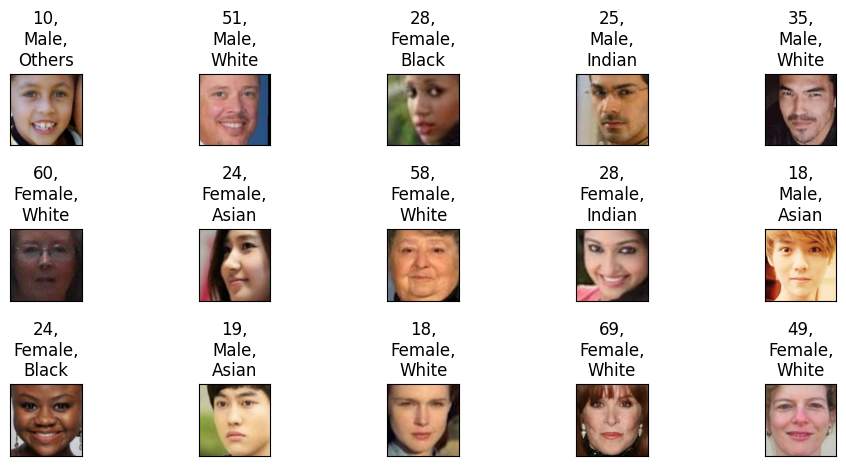

In [21]:
fig, axes = plt.subplots(nrows=3, ncols=5, sharex=True, sharey=True, figsize=(10, 5))
axes = axes.flatten()
# plt.grid(visible=True, axis='both', which='major')
samples_idx = np.random.randint(0, len(images_file), 15)
for i, sample in enumerate(samples_idx):
    img_file = os.path.join(data_path, images_file[sample])
    age, gender, ethnicity, _ = images_file[sample].split('_')
    gender = 'Male' if int(gender) == 0 else 'Female'
    ethnicity = ['White', 'Black', 'Asian', 'Indian', 'Others'][int(ethnicity)]
    axes[i].imshow(Image.open(img_file))
    axes[i].set_title(f"{age},\n{gender},\n{ethnicity}")
plt.tight_layout()
plt.xticks([])
plt.yticks([])

## Creating train, test, validation data frame from `df`

In [22]:
temp, test_df = train_test_split(df, test_size=0.2, stratify=df.age, random_state=42, shuffle=True)
train_df, valid_df = train_test_split(temp, test_size=0.2, stratify=temp.age, random_state=42, shuffle=True)

train_df.shape, test_df.shape, valid_df.shape, (train_df.shape[0]+test_df.shape[0]+valid_df.shape[0])

((14626, 4), (4571, 4), (3657, 4), 22854)

In [23]:
train_df.to_csv('train_df.csv', index=False)
test_df.to_csv('test_df.csv', index=False)
valid_df.to_csv('valid_df.csv', index=False)

# transformer

In [24]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

In [29]:
class UTKDataset(Dataset):

    def __init__(self, root_dir, csv_file, transform=None):
      self.root_dir = root_dir
      self.csv_file = csv_file
      self.transform = transform
      self.data = pd.read_csv(csv_file)
      # self.gender_dict = {'Male': 0, 'Female': 1}
      # self.ethnicity_dict = {}

    def __len__(self):
      return len(self.data)

    def __getitem__(self, idx):
      sample = self.data.iloc[idx, :]

      img_name = sample.file_name
      img = Image.open(os.path.join(self.root_dir, img_name))

      age = torch.tensor([sample.age], dtype=torch.float32)
      gender = torch.tensor([sample.gender], dtype=torch.int32)
      ethnicity = sample.ethnicity

      img = self.transform(img)

      return img, age#, gender, ethnicity

In [32]:
temp_dataset = UTKDataset(root_dir=data_path,
                          csv_file='./valid_df.csv',
                          transform=test_transform)

temp_dataset.data, len(temp_dataset)
temp_dataset[0][1]

tensor([54.])

In [39]:
temp_dataset[0][0].shape

torch.Size([3, 128, 128])

file_name    45_0_3_20170117175453472.jpg.chip.jpg
age                                             45
gender                                           0
ethnicity                                        3
Name: 0, dtype: object

## dataset and dataloader

In [54]:
train_set = UTKDataset(root_dir=data_path,
                       csv_file='train_df.csv', 
                       transform=train_transform)
test_set = UTKDataset(root_dir=data_path,
                       csv_file='test_df.csv', 
                       transform=test_transform)
valid_set = UTKDataset(root_dir=data_path,
                       csv_file='valid_df.csv', 
                       transform=test_transform)

In [55]:
train_set.data.shape, test_set.data.shape, valid_set.data.shape

((14626, 4), (4571, 4), (3657, 4))

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


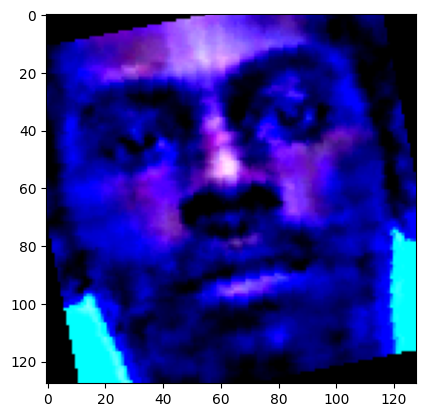

In [59]:
plt.imshow(train_set[4][0].permute(1, 2, 0))

In [64]:
train_loader = DataLoader(train_set, batch_size=128, shuffle=True)
test_loader = DataLoader(test_set, batch_size=256, shuffle=False)
valid_loader = DataLoader(valid_set, batch_size=256, shuffle=False)

In [65]:
train_iter = iter(train_loader)

In [68]:
imgs, ages = next(train_iter)

In [69]:
imgs.shape

torch.Size([128, 3, 128, 128])

# Utils

In [80]:
class AverageMeter(object):
    """Computes and stores the average and current value"""
    def __init__(self):
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


In [81]:
def num_trainable_params(model):
  nums = sum(p.numel() for p in model.parameters() if p.requires_grad)/1e6
  return nums

# Model

In [62]:
model = models.resnet50()
model.fc = nn.Linear(in_features=2048, out_features=1, bias=True)
model;

In [70]:
model(imgs).shape

torch.Size([128, 1])

In [71]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [74]:
class AgeEstimationModel(nn.Module):

  def __init__(self):
    super().__init__()
    self.model = models.resnet50()
    self.model.fc = nn.Linear(in_features=2048, out_features=1, bias=True)

  def forward(self, x):
    y = self.model(x)
    return y

In [75]:
model = AgeEstimationModel()
model(imgs).shape

torch.Size([128, 1])

In [76]:
model = model.to(device)

In [77]:
loss_fn = nn.L1Loss()
loss_fn

L1Loss()

In [78]:
optimizer = optim.SGD(model.parameters(), lr=0.02, momentum=0.9, weight_decay=1e-4)
optimizer

SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.02
    maximize: False
    momentum: 0.9
    nesterov: False
    weight_decay: 0.0001
)

In [79]:
metric = tm.MeanAbsoluteError().to(device)
metric

MeanAbsoluteError()

In [84]:
epochs = 1

for epoch in range(epochs):
  for inputs, targets in train_loader:
    inputs = inputs.to(device)
    targets = targets.to(device)
    outputs = model(inputs)
    loss = loss_fn(outputs, targets)
    loss.backward()
    optimizer.step()
    optimizer.zero_grad()
  print(loss)

tensor(12.5446, device='cuda:0', grad_fn=<MeanBackward0>)


In [85]:
with tqdm.tqdm(range(1000000)) as aa:
  for a in aa:
    b = np.exp(a/1000000)

100%|████████████████████████| 1000000/1000000 [00:00<00:00, 2103507.75it/s]


In [86]:
def train_one_epoch(model, train_loader, loss_fn, optimizer, metric, epoch=None):
  model.train()
  loss_train = AverageMeter()
  metric.reset()

  with tqdm.tqdm(train_loader, unit='batch') as tepoch:
    for inputs, targets in tepoch:
      if epoch:
        tepoch.set_description(f'Epoch {epoch}')

      inputs = inputs.to(device)
      targets = targets.to(device)

      outputs = model(inputs)

      loss = loss_fn(outputs, targets)

      loss.backward()

      optimizer.step()
      optimizer.zero_grad()

      loss_train.update(loss.item(), n=len(targets))
      metric.update(outputs, targets)

      tepoch.set_postfix(loss=loss_train.avg, metric=metric.compute().item())

  return model, loss_train.avg, metric.compute().item()

In [88]:
# train_one_epoch(model, train_loader, loss_fn, optimizer, metric, epoch=1)

In [90]:
model.eval()
with torch.inference_mode():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device)
        outputs = model(inputs)
        loss = loss_fn(outputs, targets)
        metric(outputs, targets)

In [91]:
def evaluate(model, test_loader, loss_fn, metric):
  model.eval()
  loss_eval = AverageMeter()
  metric.reset()

  with torch.inference_mode():
    for inputs, targets in test_loader:
      inputs = inputs.to(device)
      targets = targets.to(device)

      outputs = model(inputs)

      loss = loss_fn(outputs, targets)
      loss_eval.update(loss.item(), n=len(targets))

      metric(outputs, targets)

  return loss_eval.avg, metric.compute().item()

In [92]:
evaluate(model, valid_loader, loss_fn, metric)

(10.889585472567994, 10.889586448669434)

In [93]:
model = AgeEstimationModel().to(device)

inputs, targets = next(iter(train_loader))
inputs = inputs.to(device)
targets = targets.to(device)

with torch.no_grad():
  outputs = model(inputs)
  loss = loss_fn(outputs, targets)

print(loss)

tensor(32.7699, device='cuda:0')


In [94]:
torch.cuda.empty_cache()

temp = torch.tensor(1, device=device)
model = temp.clone()
optimizer = temp.clone()
inputs = temp.clone()
targets = temp.clone()
outputs = temp.clone()

## finding the best hyperparameters

In [96]:
mini_train_size = 1000
_, mini_train_dataset = random_split(train_set, (len(train_set)-mini_train_size, mini_train_size))
mini_train_loader = DataLoader(mini_train_dataset, 20)

In [97]:
model = AgeEstimationModel().to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

In [98]:
num_epochs = 10
for epoch in range(num_epochs):
    model, _, _ = train_one_epoch(model, mini_train_loader, loss_fn, optimizer, metric, epoch)

Epoch 9: 100%|███| 50/50 [00:04<00:00, 12.23batch/s, loss=12.7, metric=12.7]


In [99]:
num_epochs = 3

for lr in [0.1, 0.01, 0.001, 0.0001]:
    print(f'LR={lr}')
    
    model = AgeEstimationModel().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=1e-4, momentum=0.9)
    
    for epoch in range(num_epochs):
    model, _, _ = train_one_epoch(model, train_loader, loss_fn, optimizer, metric, epoch)
    
    print()

LR=0.1


Epoch 2: 100%|█| 115/115 [00:58<00:00,  1.98batch/s, loss=13.5, metric=13.5]



LR=0.01


Epoch 2: 100%|█| 115/115 [00:59<00:00,  1.92batch/s, loss=9.43, metric=9.43]



LR=0.001


Epoch 2: 100%|█| 115/115 [00:59<00:00,  1.92batch/s, loss=12.6, metric=12.6]



LR=0.0001


Epoch 2: 100%|█| 115/115 [01:00<00:00,  1.90batch/s, loss=13.5, metric=13.5]

In [100]:
num_epochs = 5

for lr in [0.005, 0.003, 0.001, 0.0007, 0.0005]:
  for wd in [1e-4, 1e-5, 0.]:
    print(f'LR={lr}, WD={wd}')

    model = AgeEstimationModel().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=wd)

    for epoch in range(num_epochs):
      model, loss, _ = train_one_epoch(model, train_loader, loss_fn, optimizer, epoch)

    print()

LR=0.005, WD=0.0001


AttributeError: 'int' object has no attribute 'reset'

In [101]:
model = AgeEstimationModel().to(device)

In [102]:
lr = 0.01
wd = 1e-4
optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=wd, momentum=0.9)

In [103]:
loss_train_hist = []
loss_valid_hist = []

metric_train_hist = []
metric_valid_hist = []

best_loss_valid = torch.inf
epoch_counter = 0

In [104]:
num_epochs = 10

for epoch in range(num_epochs):
    # Train
    model, loss_train, metric_train = train_one_epoch(model,
                                                 train_loader,
                                                 loss_fn,
                                                 optimizer,
                                                 metric,
                                                 epoch)
    # Validation
    loss_valid, metric_valid = evaluate(model,
                                     valid_loader,
                                     loss_fn,
                                     metric)
    
    loss_train_hist.append(loss_train)
    loss_valid_hist.append(loss_valid)
    
    metric_train_hist.append(metric_train)
    metric_valid_hist.append(metric_valid)
    
    if loss_valid < best_loss_valid:
    torch.save(model, f'model.pt')
    best_loss_valid = loss_valid
    print('Model Saved!')
    
    print(f'Valid: Loss = {loss_valid:.4}, MAE = {metric_valid:.4}')
    print()
    
    epoch_counter += 1

100%|██████████| 115/115 [00:58<00:00,  1.98batch/s, loss=14.1, metric=14.1]


Model Saved!
Valid: Loss = 12.31, MAE = 12.31



Epoch 1: 100%|█| 115/115 [00:59<00:00,  1.94batch/s, loss=10.9, metric=10.9]


Model Saved!
Valid: Loss = 10.52, MAE = 10.52



Epoch 2: 100%|█| 115/115 [00:57<00:00,  2.00batch/s, loss=9.62, metric=9.62]


...

Model Saved!
Valid: Loss = 7.017, MAE = 7.017



Epoch 8: 100%|█| 115/115 [00:58<00:00,  1.97batch/s, loss=7.05, metric=7.05]


Valid: Loss = 7.835, MAE = 7.835



Epoch 9: 100%|█| 115/115 [01:09<00:00,  1.65batch/s, loss=6.94, metric=6.94]


Model Saved!
Valid: Loss = 6.587, MAE = 6.587



In [107]:
num_epochs = 10

for epoch in range(num_epochs):
    # Train
    model, loss_train, metric_train = train_one_epoch(model,
                                                 train_loader,
                                                 loss_fn,
                                                 optimizer,
                                                 metric,
                                                 epoch)
    # Validation
    loss_valid, metric_valid = evaluate(model,
                                     valid_loader,
                                     loss_fn,
                                     metric)
    
    loss_train_hist.append(loss_train)
    loss_valid_hist.append(loss_valid)
    
    metric_train_hist.append(metric_train)
    metric_valid_hist.append(metric_valid)
    
    if loss_valid < best_loss_valid:
        torch.save(model, f'model.pt')
        best_loss_valid = loss_valid
        print('Model Saved!')
    
    print(f'Valid: Loss = {loss_valid:.4}, MAE = {metric_valid:.4}')
    print()
    
    epoch_counter += 1

100%|████████████| 115/115 [00:57<00:00,  1.99batch/s, loss=6.7, metric=6.7]


Valid: Loss = 10.52, MAE = 10.52



Epoch 1: 100%|█| 115/115 [00:57<00:00,  2.01batch/s, loss=6.74, metric=6.74]


Valid: Loss = 6.618, MAE = 6.618



Epoch 2: 100%|█| 115/115 [01:05<00:00,  1.76batch/s, loss=6.41, metric=6.41]


...

Valid: Loss = 8.28, MAE = 8.28



Epoch 8: 100%|█| 115/115 [01:02<00:00,  1.85batch/s, loss=5.75, metric=5.75]


Model Saved!
Valid: Loss = 6.121, MAE = 6.121



Epoch 9: 100%|█| 115/115 [00:58<00:00,  1.95batch/s, loss=5.59, metric=5.59]


Valid: Loss = 6.226, MAE = 6.226



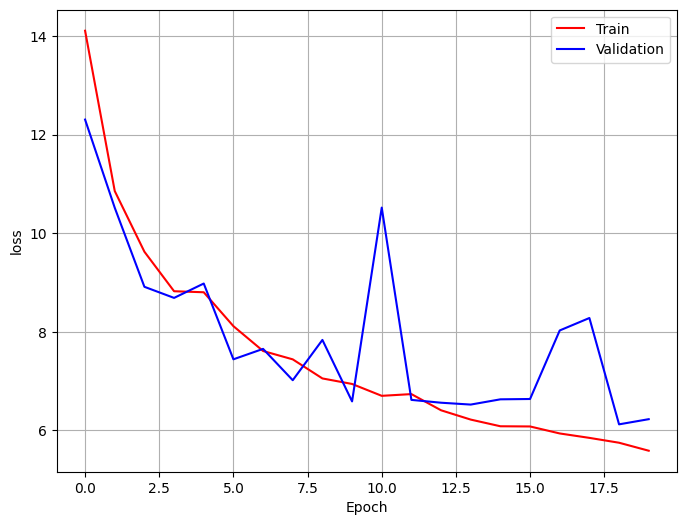

In [108]:
plt.figure(figsize=(8, 6))

plt.plot(range(epoch_counter), loss_train_hist, 'r-', label='Train')
plt.plot(range(epoch_counter), loss_valid_hist, 'b-', label='Validation')

plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid(True)
plt.legend()

In [121]:
# model_path = './model.pt'
# model_loaded = torch.load(model_path, weights_only=False)
# model_loaded.eval()

In [117]:
loss_valid, metric_valid = evaluate(model_loaded,
                                     valid_loader,
                                     loss_fn,
                                     metric)

In [114]:
loss_valid

6.226230538018519

In [118]:
loss_valid

6.121398339285888

In [276]:
def inference(image_path, transform, model, face_detection=False):
    if face_detection:
        img = face_recognition.load_image_file(image_path)
        top, right, bottom, left = face_recognition.face_locations(img)[0]
        img_crop = img[top:bottom, left:right]
        img_crop = Image.fromarray(img_crop)
    else:
        img_crop = Image.open(image_path).convert('RGB')
    
    img_tensor = transform(img_crop).unsqueeze(0)
    print(img_tensor.shape)
    with torch.inference_mode():
        preds = model(img_tensor.to(device)).item()
    
    return preds, img_crop

torch.Size([1, 3, 128, 128])
Real: None, Predicted: 24.44


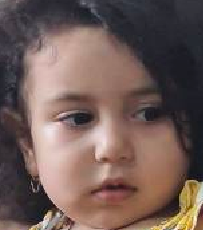

In [339]:
# Load a random image from a folder
folder_image_path = './data/personal/'
image_files = os.listdir(folder_image_path)

rand_idx = random.randint(0, len(image_files)-1)
test_image_path = os.path.join(folder_image_path, image_files[rand_idx])
predicted_age, image = inference(test_image_path, test_transform, model)

# real_age = image_files[rand_idx].split('_')[0]
print(f"Real: {None}, Predicted: {predicted_age:.2f}")
image

In [191]:
image_files

['alireza4.png', 'alireza1.png', 'alireza2.png', 'ariana.png', 'alireza3.png']

In [201]:
rand_idx

5

In [213]:
len(image_files)

5

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])